In [1]:
import ast
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import  AddHs, Draw
from rdkit.Chem.Draw import MolsToGridImage
from pathlib import Path

drawer = Draw.rdMolDraw2D.MolDraw2DSVG(200, 200)
options = drawer.drawOptions()
options.legendFontSize = 24

# Data imports

In [2]:
cwd = Path.cwd()
project_root = cwd.parent

# Lists are saved as strings, so we need to convert them back to lists
def str_to_list(val):
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        try:
            return ast.literal_eval(val)
        except Exception:
            return val
    return val


# Generated with AQME 2.0.0
full_descriptor_path = project_root / 'xtb_regiochemical_prediction/aqme_outputs_neutral/descriptors/raw_data/AQME-ROBERT_full_AQME_run.csv'
descriptors_full = pd.read_csv(full_descriptor_path)
descriptors_full = descriptors_full.dropna(axis=1, how='all')

smiles_path = project_root / 'xtb_regiochemical_prediction/smiles.csv'
smiles_df = pd.read_csv(smiles_path)
smiles_df['mol'] = smiles_df['SMILES'].apply(Chem.MolFromSmiles)
smiles_df['mol'] = smiles_df['mol'].apply(AddHs)

descriptors_full = descriptors_full.map(str_to_list)


# PROTONATED DESCRIPTORS


# Generated with AQME 2.0.0
full_descriptor_path_protonated = project_root / 'xtb_regiochemical_prediction/aqme_outputs_protonated/descriptors/raw_data/AQME-ROBERT_full_AQME_run.csv'
descriptors_full_protonated = pd.read_csv(full_descriptor_path_protonated)
descriptors_full_protonated = descriptors_full_protonated.dropna(axis=1, how='all')

smiles_path_protonated = project_root / 'xtb_regiochemical_prediction/smiles_protonated.csv'
smiles_df_protonated = pd.read_csv(smiles_path_protonated)
smiles_df_protonated['mol'] = smiles_df_protonated['SMILES'].apply(Chem.MolFromSmiles)
smiles_df_protonated['mol'] = smiles_df_protonated['mol'].apply(AddHs)

descriptors_full_protonated = descriptors_full_protonated.map(str_to_list)

# Filter the df to only include columns containing list values
is_list_col = descriptors_full.map(lambda x: isinstance(x, list)).any()
descriptors_list = descriptors_full.loc[:, is_list_col]
descriptors_list = pd.concat([descriptors_full['code_name'], descriptors_list], axis=1)
descriptors_list = descriptors_list.sort_values('code_name').reset_index(drop=True)

is_list_col_protonated = descriptors_full_protonated.map(lambda x: isinstance(x, list)).any()
descriptors_list_protonated = descriptors_full_protonated.loc[:, is_list_col_protonated]
descriptors_list_protonated = pd.concat([descriptors_full_protonated['code_name'], descriptors_list_protonated], axis=1)
descriptors_list_protonated = descriptors_list_protonated.sort_values('code_name').reset_index(drop=True)

## Indexing investigations

In [3]:
mol = smiles_df['mol'][0]
num_atoms = mol.GetNumAtoms()
len_descriptors = len(descriptors_list.iloc[0,3])
print(f'Number of atoms for {smiles_df.loc[0, 'code_name']} in mol is {num_atoms}')
print(f'Length of {descriptors_list.loc[0, 'code_name']} descriptor lists is {len_descriptors}')  # Exclude 'code_name'

Number of atoms for Bifonazole in mol is 42
Length of Bifonazole descriptor lists is 42


In [4]:
def get_max_index(df, col_name):
    """Get the maximum index from the list in the specified column."""
    values = df[col_name].apply(lambda x: [int(np.argmax(x))] if isinstance(x, list) and len(x) > 0 else [])
    return values.tolist()

In [6]:
print(descriptors_list.columns)

Index(['code_name', 'Partial charge', 'Atom SASA', 'Buried volume',
       'H bond H2O', 'Fukui+', 'Fukui-', 'Electrophil.',
       'Normaliz. electrophil.', 'Normaliz. nucleophil.', 'Fukui_rad',
       'Fukui dual', 'Dipole moment', 'Coord. numbers', 'Atom Polarizability',
       'Atom FOD', 'Atom dispersion', 'Pyramidalization',
       'Pyramidaliz. volume'],
      dtype='object')


Highlight lists: [[2], [19], [3], [16], [2], [4], [1], [38], [11], [20], [0], [12], [3], [8], [14], [26], [12], [9], [49], [19], [11], [3], [1], [12], [13], [12], [49], [17], [17], [14], [24]]


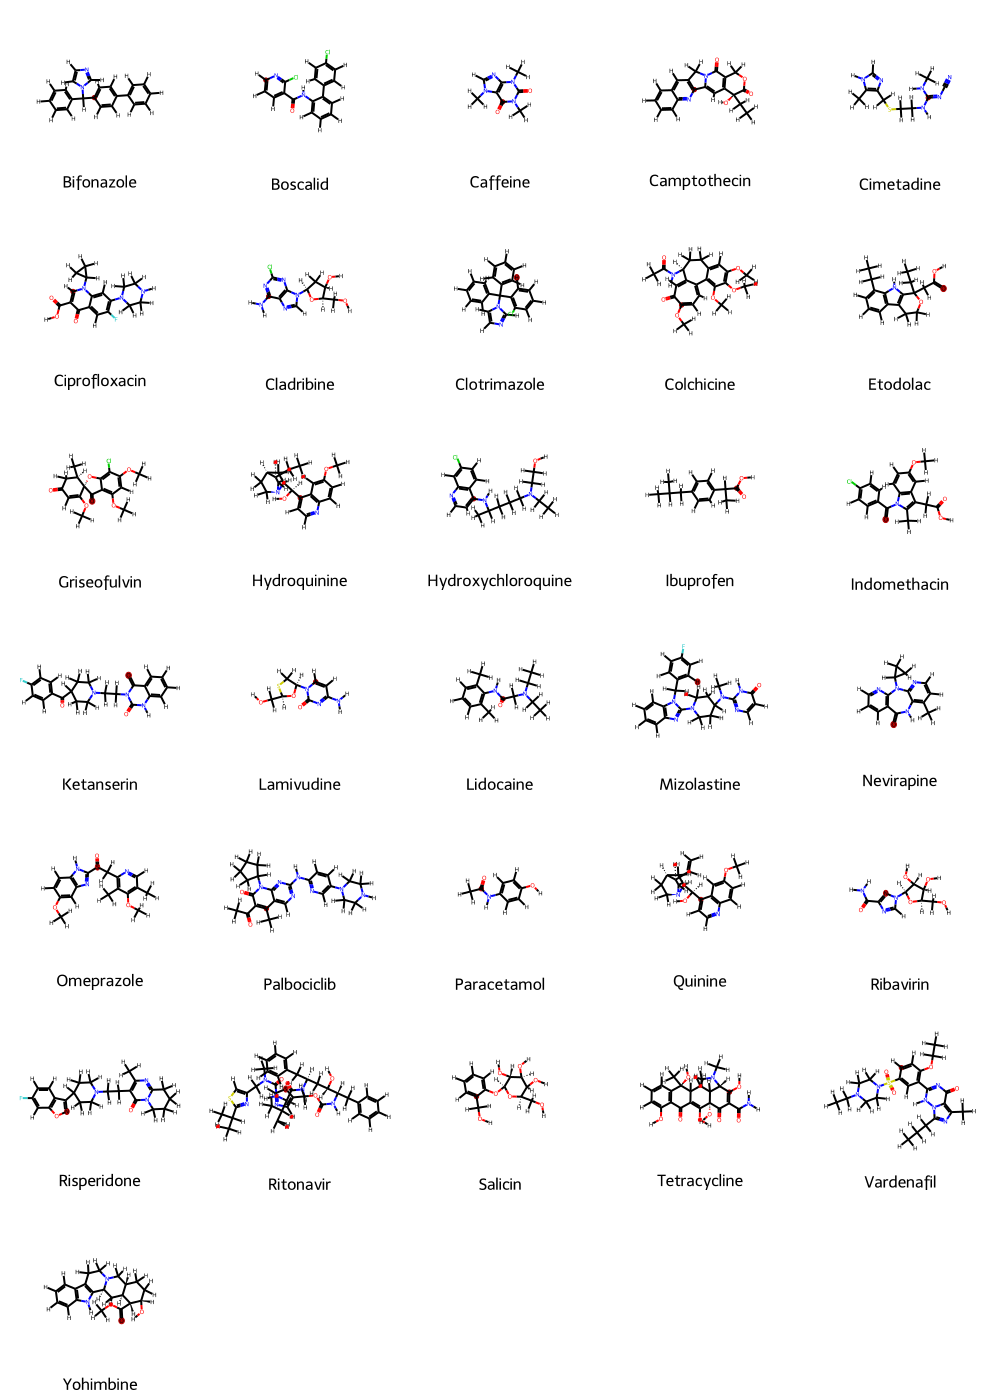

In [7]:
# Highlight the maximum index in the specified descripptor
value_to_highlight = 'Fukui dual'

if value_to_highlight not in descriptors_list.columns:
    raise ValueError(f"Column '{value_to_highlight}' not found in descriptors_list.")

highlight_lists = get_max_index(descriptors_list, value_to_highlight)
print(f'Highlight lists: {highlight_lists}')

deep_red = (0.7, 0, 0)  # Example deep red color
highlight_colors = [{lst[0]: deep_red} for lst in highlight_lists]

img = MolsToGridImage(
    smiles_df['mol'].tolist(),
    molsPerRow=5,
    subImgSize=(200, 200),
    legends=smiles_df['code_name'].tolist(),
    useSVG=True,
    highlightAtomLists=highlight_lists,
    highlightAtomColors=highlight_colors  # This draws a colored circle around the atom
)
img

Atoms selected tended to be heteroatoms. Potentially more useful would be information about the most nucleophilic aromatic carbon bonded to a hydrogen...

In [8]:
# Function to find aromatic carbons with a bonded hydrogen
def aromatic_carbons_with_CH(mol):
    return [
        idx for idx in range(mol.GetNumAtoms())
        if (
            mol.GetAtomWithIdx(idx).GetSymbol() == 'C' # Carbon atom
            and mol.GetAtomWithIdx(idx).GetIsAromatic() # Aromatic carbon
            and mol.GetAtomWithIdx(idx).GetTotalNumHs(includeNeighbors=True) > 0 # Aromatic carbon a bonded hydrogen
        )
    ]

Aromatic carbons with CH of Ciprofloxacin: [4, 7, 17]


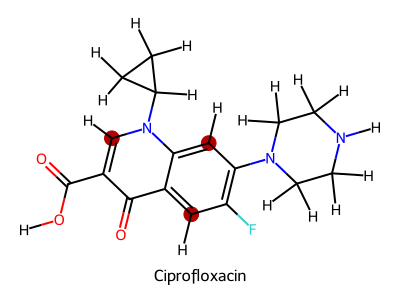

In [9]:
mol_index = 5 # The index of the molecule, not the atoms

mol = smiles_df['mol'][mol_index]
atom_indices = aromatic_carbons_with_CH(mol)
print(f'Aromatic carbons with CH of {smiles_df.loc[mol_index, "code_name"]}: {atom_indices}')

atom_labels = {idx: str(idx) for idx in atom_indices}
img = Draw.MolToImage(
    mol,
    size=(400, 300),
    legend=smiles_df.loc[mol_index, "code_name"],
    highlightAtoms=atom_indices,  
    highlightColor=(0.7, 0, 0)           
)
img

In [10]:
# Extract the values corresponding to the highlighted atoms
def extract_max_ch_value(mol, values, n_top=1):
    atom_indices = aromatic_carbons_with_CH(mol)
    ch_values = [values[idx] for idx in atom_indices]
    # Filter out None values and keep track of original indices
    valid_pairs = [(v, idx) for v, idx in zip(ch_values, atom_indices) if v is not None]
    if not valid_pairs:
        return []
    valid_values, valid_indices = zip(*valid_pairs)
    maxs = np.argsort(valid_values)[-n_top:][::-1]
    return [valid_indices[i] for i in maxs]

def extract_min_ch_value(mol, values, n_top=1):
    atom_indices = aromatic_carbons_with_CH(mol)
    ch_values = [values[idx] for idx in atom_indices]
    # Filter out None values and keep track of original indices
    valid_pairs = [(v, idx) for v, idx in zip(ch_values, atom_indices) if v is not None]
    if not valid_pairs:
        return []
    valid_values, valid_indices = zip(*valid_pairs)
    mins = np.argsort(valid_values)[:n_top]
    return [valid_indices[i] for i in mins]

def get_max_ch_index(df, smiles_df,col_name, n_top=1):
    indices = []
    for i, row in df.iterrows():
        index = extract_max_ch_value(smiles_df.loc[i,'mol'], row[col_name], n_top)
        indices.append(index)
    return indices

def get_min_ch_index(df, smiles_df, col_name, n_top=1):
    indices = []
    for i, row in df.iterrows():
        index = extract_min_ch_value(smiles_df.loc[i,'mol'], row[col_name], n_top)
        indices.append(index)
    return indices


Highlight lists: [[9], [17], [10], [23], [12], [7], [9], [22], [25], [5], [6], [18], [4], [12], [16], [22], [13], [2], [5], [11], [16], [12], [6], [18], [7], [20], [8], [13], [4], [13], [6]]


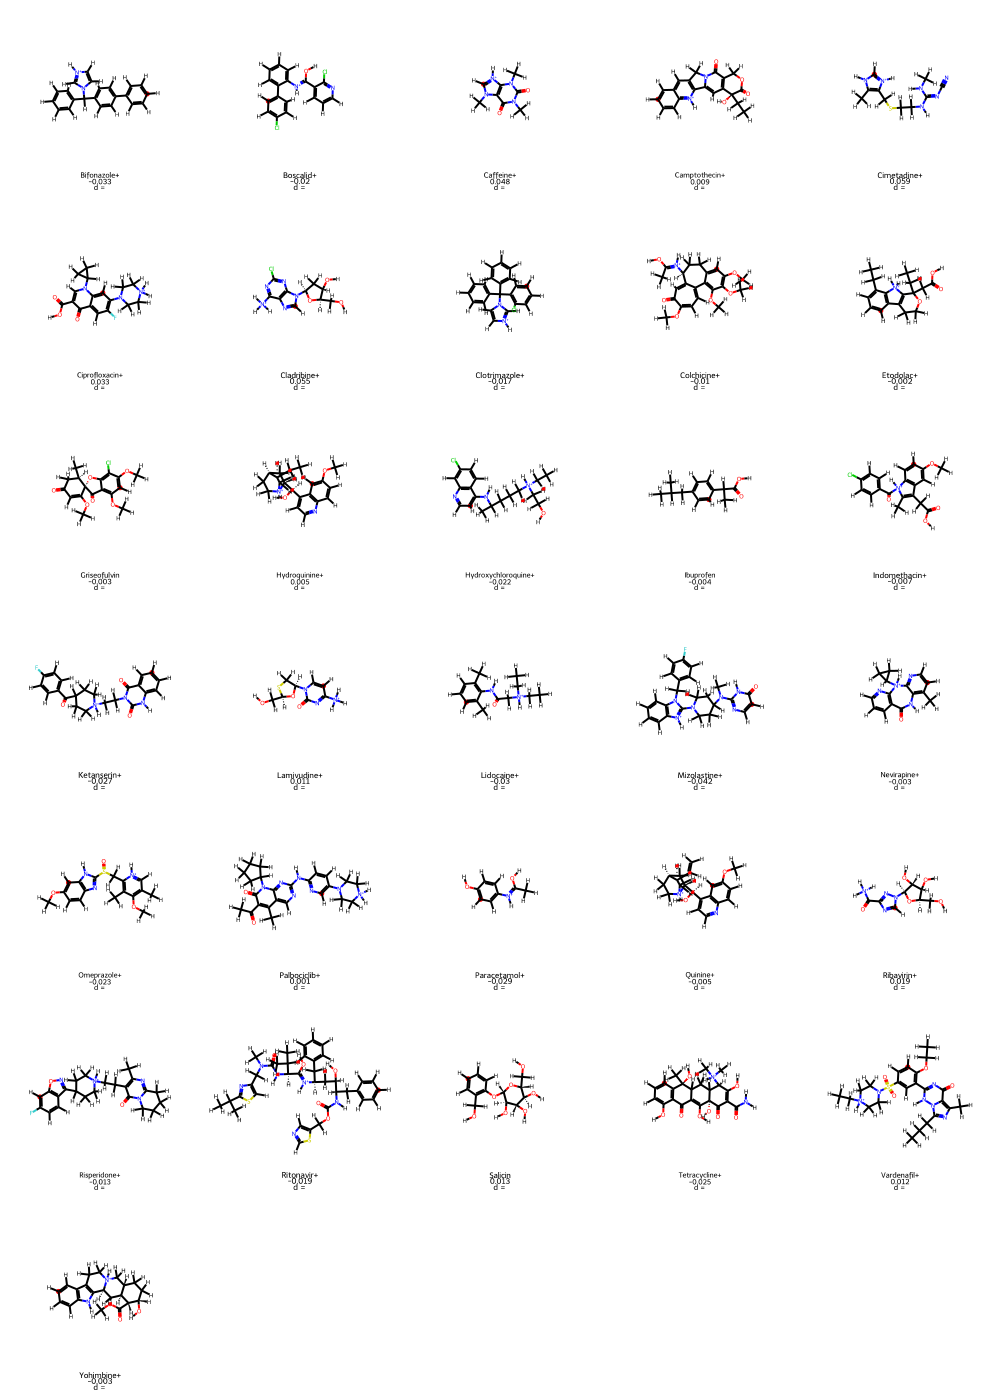

In [11]:

def plot_atomic_descriptors(value_to_highlight, descriptors, smiles, by='max'):
    if value_to_highlight not in descriptors.columns:
        raise ValueError(f"Column '{value_to_highlight}' not found in descriptors.")

    if by == 'max':
        highlight_lists = get_max_ch_index(descriptors, smiles, value_to_highlight)
    elif by == 'min':
        highlight_lists = get_min_ch_index(descriptors, smiles, value_to_highlight)
    else:
        raise ValueError(f"Invalid value for 'by'. Expected 'max' or 'min', got '{by}'.")

    print(f'Highlight lists: {highlight_lists}')

    color = (1, 0, 0)
    highlight_colors = [{lst[0]: color} for lst in highlight_lists]

    max_values = [descriptors.loc[x, value_to_highlight][lst[0]] for x, lst in enumerate(highlight_lists)]
    second_max_values = [descriptors.loc[x, value_to_highlight][lst[1]] if len(lst) > 1 else None for x, lst in enumerate(highlight_lists)]

    lables = [
        f'{x}\n{np.round(y, 5)}\n{np.round(z, 5) if z is not None else ""}\nd = {np.round(abs(y - z), 5) if z is not None else ""}'
        for x, y, z in zip(smiles['code_name'], max_values, second_max_values)
    ]

    img = MolsToGridImage(
        smiles['mol'].tolist(),
        molsPerRow=5,
        subImgSize=(200, 200),
        legends=lables,
        useSVG=True,
        highlightAtomLists=highlight_lists,
        highlightAtomColors=highlight_colors,
        #removeHs=True
    )
    return img

# Highlight the maximum index in the specified descripptor
value_to_highlight = 'Fukui dual'
img = plot_atomic_descriptors(value_to_highlight, descriptors_list_protonated, smiles_df_protonated, by='min')
img

## Finding the indexes of the halogenated carbons for the major product of each testing set

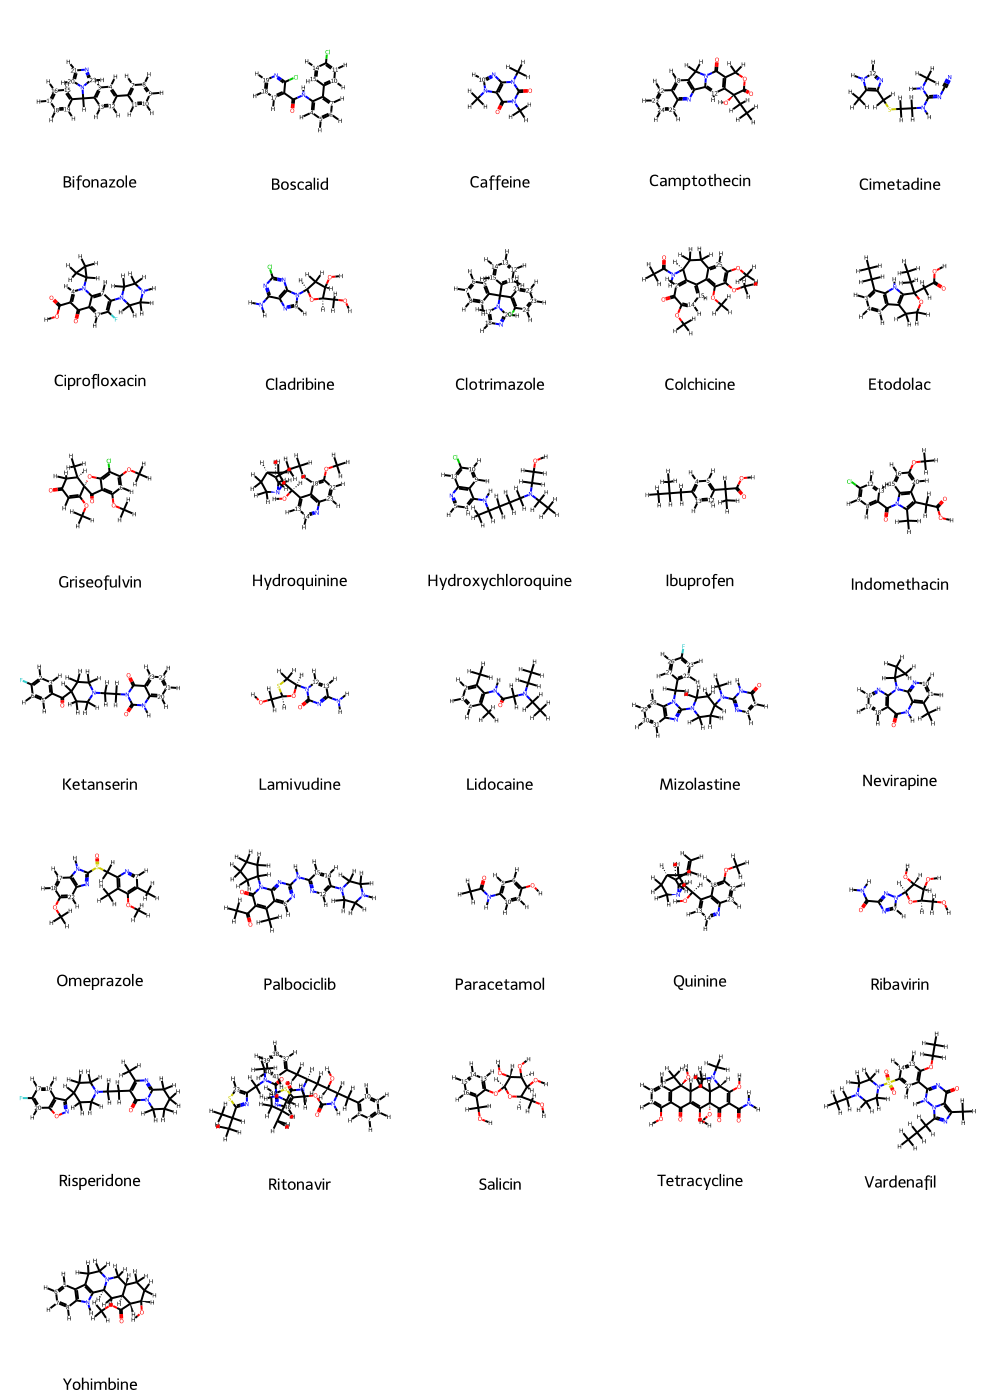

In [12]:
labeled_mols = []
for mol in smiles_df['mol']:
    mol = Chem.Mol(mol)  # Copy molecule
    for idx in aromatic_carbons_with_CH(mol):
        mol.GetAtomWithIdx(idx).SetProp("_displayLabel", str(idx))
    labeled_mols.append(mol)

img = MolsToGridImage(
    labeled_mols,
    molsPerRow=5,
    subImgSize=(200, 200),
    legends=smiles_df['code_name'].tolist(),
    useSVG=True,
)
img

In [15]:
# List of halogenated substrates with their halogenated carbon index. Nan denotes no halogenated carbon experimentally observed in HTE
halogenated_carbons = [{'code_name': 'Bifonazole', 'halogenated_index': 9},
                       {'code_name': 'Boscalid', 'halogenated_index': 6},
                       {'code_name': 'Caffeine', 'halogenated_index': 10},
                       {'code_name': 'Camptothecin', 'halogenated_index': 12},
                       {'code_name': 'Cimetadine', 'halogenated_index': np.nan},
                       {'code_name': 'Ciprofloxacin', 'halogenated_index': 7},
                       {'code_name': 'Cladribine', 'halogenated_index': np.nan},
                       {'code_name': 'Clotrimazole', 'halogenated_index': np.nan},
                       {'code_name': 'Colchicine', 'halogenated_index': 25},
                       {'code_name': 'Etodolac', 'halogenated_index': np.nan},
                       {'code_name': 'Griseofulvin', 'halogenated_index': 6},
                       {'code_name': 'Hydroquinine', 'halogenated_index': 18},
                       {'code_name': 'Hydroxychloroquine', 'halogenated_index': 4},
                       {'code_name': 'Ibuprofen', 'halogenated_index': 4},
                       {'code_name': 'Indomethacin', 'halogenated_index': 16},
                       {'code_name': 'Ketanserin', 'halogenated_index': 22},
                       {'code_name': 'Lamivudine', 'halogenated_index': np.nan},
                       {'code_name': 'Lidocaine', 'halogenated_index': 2},
                       {'code_name': 'Mizolastine', 'halogenated_index': 5},
                       {'code_name': 'Nevirapine', 'halogenated_index': 11},
                       {'code_name': 'Omeprazole', 'halogenated_index': np.nan},
                       {'code_name': 'Palbociclib', 'halogenated_index': 12},
                       {'code_name': 'Paracetamol', 'halogenated_index': 6},
                       {'code_name': 'Quinine', 'halogenated_index': 18},
                       {'code_name': 'Ribavirin', 'halogenated_index': np.nan},
                       {'code_name': 'Risperidone', 'halogenated_index': 17},
                       {'code_name': 'Ritonavir', 'halogenated_index': 23},
                       {'code_name': 'Salicin', 'halogenated_index': 15},
                       {'code_name': 'Tetracycline', 'halogenated_index': np.nan},
                       {'code_name': 'Vardenafil', 'halogenated_index': 13},
                       {'code_name': 'Yohimbine', 'halogenated_index': 6},
                       ]

ch_index_df = pd.DataFrame(halogenated_carbons)
ch_index_df.shape

(31, 2)

# What max/min descriptor is the best predictor of regiochemistry

In [16]:
list_columns = descriptors_list.columns[2:]
list_columns  # Exclude 'code_name' and 'code_name' column#

Index(['Atom SASA', 'Buried volume', 'H bond H2O', 'Fukui+', 'Fukui-',
       'Electrophil.', 'Normaliz. electrophil.', 'Normaliz. nucleophil.',
       'Fukui_rad', 'Fukui dual', 'Dipole moment', 'Coord. numbers',
       'Atom Polarizability', 'Atom FOD', 'Atom dispersion',
       'Pyramidalization', 'Pyramidaliz. volume'],
      dtype='object')

In [17]:
# Create a new DataFrames with the indicies of the 2 maximum and 2 minimum values for each descriptor

for column in list_columns:
    column_name_max = f'{column}_ch_max'
    column_name_min = f'{column}_ch_min'

    output_max = get_max_ch_index(descriptors_list, smiles_df, column, n_top=2)
    output_min = get_min_ch_index(descriptors_list, smiles_df, column, n_top=2)

    values_max = [x[:] for x in output_max]
    values_min = [x[:] for x in output_min]

    ch_index_df[column_name_max] = values_max
    ch_index_df[column_name_min] = values_min

# Drop columns where all values are empty lists
cols_to_drop = [col for col in ch_index_df.columns if ch_index_df[col].apply(lambda x: isinstance(x, list) and len(x) == 0).all()]
ch_index_df = ch_index_df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
ch_index_df.head()

Dropped 6 columns: ['Buried volume_ch_max', 'Buried volume_ch_min', 'Pyramidalization_ch_max', 'Pyramidalization_ch_min', 'Pyramidaliz. volume_ch_max', 'Pyramidaliz. volume_ch_min']


,code_name,halogenated_index,Atom SASA_ch_max,Atom SASA_ch_min,H bond H2O_ch_max,H bond H2O_ch_min,Fukui+_ch_max,Fukui+_ch_min,Fukui-_ch_max,Fukui-_ch_min,...,Dipole moment_ch_max,Dipole moment_ch_min,Coord. numbers_ch_max,Coord. numbers_ch_min,Atom Polarizability_ch_max,Atom Polarizability_ch_min,Atom FOD_ch_max,Atom FOD_ch_min,Atom dispersion_ch_max,Atom dispersion_ch_min
0,Bifonazole,9.0,"[21, 9]","[3, 19]","[23, 12]","[3, 20]","[9, 17]","[20, 23]","[9, 17]","[19, 23]",...,"[20, 23]","[7, 11]","[23, 21]","[8, 10]","[15, 13]","[23, 21]","[9, 20]","[8, 10]","[3, 19]","[21, 9]"
1,Boscalid,6.0,"[19, 18]","[15, 10]","[19, 18]","[4, 5]","[19, 17]","[11, 10]","[5, 6]","[17, 19]",...,"[19, 6]","[11, 17]","[11, 14]","[18, 19]","[4, 11]","[19, 17]","[19, 17]","[11, 14]","[10, 11]","[19, 18]"
2,Caffeine,10.0,[10],[10],[10],[10],[10],[10],[10],[10],...,[10],[10],[10],[10],[10],[10],[10],[10],[10],[10]
3,Camptothecin,12.0,"[23, 24]","[12, 18]","[25, 24]","[12, 18]","[18, 23]","[12, 24]","[12, 23]","[25, 18]",...,"[25, 12]","[18, 23]","[25, 18]","[12, 23]","[12, 25]","[24, 23]","[18, 12]","[24, 23]","[12, 18]","[24, 23]"
4,Cimetadine,NaN,[12],[12],[12],[12],[12],[12],[12],[12],...,[12],[12],[12],[12],[12],[12],[12],[12],[12],[12]


# How often does each descriptor successfully identify the halogenated carbon from the scope?

In [18]:
# Filter the DataFrame to only include successfully halogenated substrates and calculate the F values

halogenated_substrates_df = ch_index_df[ch_index_df['halogenated_index'].notna()]

f_values = []

for column in halogenated_substrates_df.columns[2:]:
    truth_list = [x == y[0] for x, y in zip(halogenated_substrates_df['halogenated_index'], halogenated_substrates_df[column]) if isinstance(y, list) and len(y) > 0]
    f_value = sum(truth_list) / len(truth_list) if truth_list else 0
    f_values.append(f_value)

f_values_df = pd.DataFrame({
    'descriptor': halogenated_substrates_df.columns[2:],
    'f_value': f_values
})
f_values_df = f_values_df.sort_values('f_value', ascending=False).reset_index(drop=True)

# Save the results to a CSV file
output_path = project_root / 'xtb_regiochemical_prediction/f_values_top1.csv'
f_values_df.to_csv(output_path, index=False)
    
f_values_df.head(10)

,descriptor,f_value
0,Fukui dual_ch_min,0.565217
1,Normaliz. nucleophil._ch_min,0.521739
2,Fukui+_ch_min,0.521739
3,Fukui-_ch_max,0.521739
4,Normaliz. electrophil._ch_min,0.521739
5,Atom Polarizability_ch_max,0.478261
6,Atom dispersion_ch_max,0.434783
7,Dipole moment_ch_max,0.434783
8,Electrophil._ch_min,0.434783
9,Atom SASA_ch_min,0.391304


# Is the correct index ranked in the top 2 selected indexes for each descriptor?

In [19]:
f_values = []

for column in halogenated_substrates_df.columns[2:]:
    truth_list = [x in y for x, y in zip(halogenated_substrates_df['halogenated_index'], halogenated_substrates_df[column])]
    f_value = sum(truth_list) / len(truth_list)
    f_values.append(f_value)

f_values_df = pd.DataFrame({
    'descriptor': halogenated_substrates_df.columns[2:],
    'f_value': f_values
})
f_values_df = f_values_df.sort_values('f_value', ascending=False).reset_index(drop=True)

# Save the results to a CSV file
output_path = project_root / 'xtb_regiochemical_prediction/f_values_top2.csv'
f_values_df.to_csv(output_path, index=False)

f_values_df.head(10)    

,descriptor,f_value
0,Atom Polarizability_ch_max,0.782609
1,Fukui dual_ch_min,0.739130
2,Fukui-_ch_max,0.739130
3,Dipole moment_ch_max,0.739130
4,Normaliz. nucleophil._ch_min,0.695652
5,Fukui+_ch_min,0.652174
6,Electrophil._ch_min,0.652174
7,Normaliz. electrophil._ch_min,0.652174
8,H bond H2O_ch_min,0.608696
9,Atom FOD_ch_min,0.565217


We then investigated the effect of using protonated structures as inputs into the algroithm...

In [21]:
# List of halogenated substrates with their halogenated carbon index for the protonated form. Nan denotes no halogenated carbon experimentally observed in HTE
halogenated_carbons_protonated = [{'code_name': 'Bifonazole+', 'halogenated_index': 9},
                       {'code_name': 'Boscalid+', 'halogenated_index': 13},
                       {'code_name': 'Caffeine+', 'halogenated_index': 10},
                       {'code_name': 'Camptothecin+', 'halogenated_index': 12},
                       {'code_name': 'Cimetadine+', 'halogenated_index': np.nan},
                       {'code_name': 'Ciprofloxacin+', 'halogenated_index': 7},
                       {'code_name': 'Cladribine+', 'halogenated_index': np.nan},
                       {'code_name': 'Clotrimazole+', 'halogenated_index': np.nan},
                       {'code_name': 'Colchicine+', 'halogenated_index': 25},
                       {'code_name': 'Etodolac+', 'halogenated_index': np.nan},
                       {'code_name': 'Griseofulvin', 'halogenated_index': 6},
                       {'code_name': 'Hydroquinine+', 'halogenated_index': 18},
                       {'code_name': 'Hydroxychloroquine+', 'halogenated_index': 4},
                       {'code_name': 'Ibuprofen', 'halogenated_index': 4},
                       {'code_name': 'Indomethacin+', 'halogenated_index': 16},
                       {'code_name': 'Ketanserin+', 'halogenated_index': 22},
                       {'code_name': 'Lamivudine+', 'halogenated_index': np.nan},
                       {'code_name': 'Lidocaine+', 'halogenated_index': 2},
                       {'code_name': 'Mizolastine+', 'halogenated_index': 5},
                       {'code_name': 'Nevirapine+', 'halogenated_index': 11},
                       {'code_name': 'Omeprazole+', 'halogenated_index': np.nan},
                       {'code_name': 'Palbociclib+', 'halogenated_index': 12},
                       {'code_name': 'Paracetamol+', 'halogenated_index': 6},
                       {'code_name': 'Quinine+', 'halogenated_index': 18},
                       {'code_name': 'Ribavirin+', 'halogenated_index': np.nan},
                       {'code_name': 'Risperidone+', 'halogenated_index': 17},
                       {'code_name': 'Ritonavir+', 'halogenated_index': 24},
                       {'code_name': 'Salicin', 'halogenated_index': 13},
                       {'code_name': 'Tetracycline+', 'halogenated_index': np.nan},
                       {'code_name': 'Vardenafil+', 'halogenated_index': 13},
                       {'code_name': 'Yohimbine+', 'halogenated_index': 6},
                       ]

ch_index_protonated_df = pd.DataFrame(halogenated_carbons_protonated)


list_columns_protonated = descriptors_list_protonated.columns[2:]
for column in list_columns_protonated:
    column_name_max = f'{column}_ch_max'
    column_name_min = f'{column}_ch_min'

    output_max = get_max_ch_index(descriptors_list_protonated, smiles_df_protonated, column, n_top=2)
    output_min = get_min_ch_index(descriptors_list_protonated, smiles_df_protonated, column, n_top=2)

    values_max = [x[:] for x in output_max]
    values_min = [x[:] for x in output_min]

    ch_index_protonated_df[column_name_max] = values_max
    ch_index_protonated_df[column_name_min] = values_min

# Drop columns where all values are empty lists
cols_to_drop = [col for col in ch_index_protonated_df.columns if ch_index_protonated_df[col].apply(lambda x: isinstance(x, list) and len(x) == 0).all()]
ch_index_protonated_df = ch_index_protonated_df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
ch_index_protonated_df.head()

halogenated_substrates_protonated_df = ch_index_protonated_df[ch_index_protonated_df['halogenated_index'].notna()]

f_values = []

for column in halogenated_substrates_protonated_df.columns[2:]:
    truth_list = [x == y[0] for x, y in zip(halogenated_substrates_protonated_df['halogenated_index'], halogenated_substrates_protonated_df[column]) if isinstance(y, list) and len(y) > 0]
    f_value = sum(truth_list) / len(truth_list) if truth_list else 0
    f_values.append(f_value)

f_values_df = pd.DataFrame({
    'descriptor': halogenated_substrates_protonated_df.columns[2:],
    'f_value': f_values
})
f_values_df = f_values_df.sort_values('f_value', ascending=False).reset_index(drop=True)

# Save the results to a CSV file
output_path = project_root / 'xtb_regiochemical_prediction/f_values_top1_protonated.csv'
f_values_df.to_csv(output_path, index=False)

f_values_df.head(10)

Dropped 6 columns: ['Buried volume_ch_max', 'Buried volume_ch_min', 'Pyramidalization_ch_max', 'Pyramidalization_ch_min', 'Pyramidaliz. volume_ch_max', 'Pyramidaliz. volume_ch_min']


,descriptor,f_value
0,Fukui dual_ch_min,0.782609
1,Fukui-_ch_max,0.608696
2,Normaliz. nucleophil._ch_min,0.608696
3,Normaliz. electrophil._ch_min,0.565217
4,Fukui+_ch_min,0.565217
5,Atom Polarizability_ch_max,0.521739
6,Fukui_rad_ch_max,0.434783
7,Electrophil._ch_min,0.434783
8,Atom FOD_ch_min,0.391304
9,Dipole moment_ch_max,0.391304


The use of protonated structure greatly improved accuracy, from 57% to 78%...

The Fukui dual values were then used to rationalise the regiochemical observations for the bromination and iodination of Indomethacin

In [22]:
indo_atomic_indexes = [16,20]

neutral_fukui_dual_indo = [descriptors_list.loc[descriptors_list['code_name'] == 'Indomethacin', 'Fukui dual'].values[0][i] for i in indo_atomic_indexes]
protonated_fukui_dual_indo = [descriptors_list_protonated.loc[descriptors_list_protonated['code_name'] == 'Indomethacin+', 'Fukui dual'].values[0][i] for i in indo_atomic_indexes]


print(f'Fukui dual values for Indomethacin 6 carbon - Neutral: {neutral_fukui_dual_indo[0]}')
print(f'Fukui dual values for Indomethacin 6 carbon - Protonated: {protonated_fukui_dual_indo[0]}')

print(f'Difference in Fukui dual values for Indomethacin - Neutral: {neutral_fukui_dual_indo[0] - neutral_fukui_dual_indo[1]}')
print(f'Difference in Fukui dual values for Indomethacin - Protonated: {protonated_fukui_dual_indo[0] - protonated_fukui_dual_indo[1]}')

print(f'Indomethacin Fukui dual values - Neutral: 6: {neutral_fukui_dual_indo[0]}, 4: {neutral_fukui_dual_indo[1]}')
print(f'Indomethacin Fukui dual values - Protonated: 6: {protonated_fukui_dual_indo[0]}, 4: {protonated_fukui_dual_indo[1]}')

Fukui dual values for Indomethacin 6 carbon - Neutral: -0.005
Fukui dual values for Indomethacin 6 carbon - Protonated: -0.007
Difference in Fukui dual values for Indomethacin - Neutral: 0.013000000000000001
Difference in Fukui dual values for Indomethacin - Protonated: -0.003
Indomethacin Fukui dual values - Neutral: 6: -0.005, 4: -0.018000000000000002
Indomethacin Fukui dual values - Protonated: 6: -0.007, 4: -0.004
